In [1]:
### Check for connected runtime (GPU or not)
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Jan 22 11:27:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
### Check for more RAM
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 179.4 gigabytes of available RAM

You are using a high-RAM runtime!


In [6]:
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0))

NameError: name 'torch' is not defined

##### Mount Drive into Collab

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##### Path to Model Repository

In [7]:
%cd /content/drive/MyDrive/Colab_Notebooks/AnySat

/content/drive/MyDrive/Colab_Notebooks/AnySat


##### Installing Model requirements

In [8]:
%pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 153.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.2/308.2 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 149.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 6.8 MB/s eta 0:00:00


# [ORIGINAL PART]

# AnySat Guide

#### Simple Usage

In [9]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
import numpy as np
import rasterio
from datetime import datetime
import h5py
import time
import psutil
import matplotlib.pyplot as plt
from IPython.display import clear_output

## AnySat is available through
### 1) PyTorch Hub
#### or
### 2) local repository

In [10]:
# 1) PyTorch Hub
#model = torch.hub.load('gastruc/anysat', 'anysat', pretrained=True, force_reload=True, flash_attn=False, trust_repo='check')

# 2) local repo
from hubconf import AnySat

model = AnySat.from_pretrained('base', flash_attn=False) #Set flash_attn=True if you have flash-attn module installed (url flash attn)
#device = "cuda" If you want to run on GPU default is cpu

Downloading: "https://huggingface.co/g-astruc/AnySat/resolve/main/models/AnySat.pth" to /root/.cache/torch/hub/checkpoints/AnySat.pth


100%|██████████| 480M/480M [00:05<00:00, 90.0MB/s]


### Added code to assure that every part of the Model runs on GPU

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the entire model and its submodules to the GPU
model = model.to(device)

# Iterate through all model parameters and move them to the GPU if not already there
for param in model.parameters():
    if param.device != device:
        param.data = param.data.to(device)

# Check for any remaining submodules not on the GPU
for name, module in model.named_modules():
    if next(module.parameters(), None) is not None and next(module.parameters()).device != device:  # Checks if module has parameters
        module.to(device)
        print(f"Module '{name}' moved to {device}")

Module '' moved to cuda
Module 'spatial_encoder' moved to cuda
Module 'spatial_encoder.predictor_blocks' moved to cuda
Module 'spatial_encoder.predictor_blocks.0' moved to cuda
Module 'spatial_encoder.predictor_blocks.0.norm1' moved to cuda
Module 'spatial_encoder.predictor_blocks.0.attn' moved to cuda
Module 'spatial_encoder.predictor_blocks.0.attn.qkv' moved to cuda
Module 'spatial_encoder.predictor_blocks.0.attn.proj' moved to cuda
Module 'spatial_encoder.predictor_blocks.0.attn.rpe_k' moved to cuda
Module 'spatial_encoder.predictor_blocks.0.norm2' moved to cuda
Module 'spatial_encoder.predictor_blocks.0.mlp' moved to cuda
Module 'spatial_encoder.predictor_blocks.0.mlp.fc1' moved to cuda
Module 'spatial_encoder.predictor_blocks.0.mlp.fc2' moved to cuda
Module 'spatial_encoder.predictor_blocks.1' moved to cuda
Module 'spatial_encoder.predictor_blocks.1.norm1' moved to cuda
Module 'spatial_encoder.predictor_blocks.1.attn' moved to cuda
Module 'spatial_encoder.predictor_blocks.1.attn.q

# Feature Extraction

In [12]:
2773 % 4
#8689 % 4

1

### Subset

In [15]:
import os
import torch
import glob
import json
import re
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader

# 🔧 Configuration

feature_set = 'test'   # either 'train' or 'test'
NUM_FILES = 2772       # Max files to process (applied AFTER filtering by ID)
ORBIT = 'asc'          # either 'asc' or 'desc'
OUTPUT_TYPE = 'dense'  # Either 'tile', 'patch', 'dense'
if OUTPUT_TYPE == 'dense':
  print("YO")

BATCH_SIZE = 2         # ✅ Set your optimal batch size here
NUM_WORKERS = 8        # ✅ Set your optimal worker count here
PATCH_SIZE = 40        # ✅ Set your optimal patch size here

# 📁 Paths

# ✅ NEW: Path to your JSON file containing the list of allowed IDs
ID_JSON_PATH = "/content/drive/MyDrive/Colab_Notebooks/Training/subset_42_278.json"

INPUT_FOLDER = f"/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/{feature_set}_features/S1_pytorch_tensors_{feature_set}_features/NORMALIZED_{feature_set.upper()}_FEATURE_TENSORS_s1_{ORBIT.lower()}_July"
OUTPUT_FOLDER = f"/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/{feature_set}_features/S1_pytorch_tensors_{feature_set}_features/ENCODED_{feature_set.upper()}_FEATURES_s1_{ORBIT}_July_PatchSize_{PATCH_SIZE}_OutputType_{OUTPUT_TYPE}_Subset-278-42"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
existing_outputs = set(os.listdir(OUTPUT_FOLDER))

model_used = model  # your pretrained model should already be defined

# ---------------------------------------------------------
# 🔍 1. Load Target IDs from JSON
# ---------------------------------------------------------
print(f"📂 Loading target IDs from: {ID_JSON_PATH}")
with open(ID_JSON_PATH, 'r') as f:
    # Load and convert to set for O(1) lookup speed
    # We ensure they are strings in case JSON has them as numbers
    target_ids = set(str(x) for x in json.load(f))

print(f"✅ Loaded {len(target_ids)} unique target IDs.")

# ---------------------------------------------------------
# 📦 Dataset Definition
# ---------------------------------------------------------
class TensorDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        tensor = torch.load(path).float()  # Shape: [2, 256, 256]
        filename = os.path.basename(path)
        return tensor, filename

# ---------------------------------------------------------
# 📁 Load and Filter File Paths
# ---------------------------------------------------------

# Get ALL files first (do not slice by NUM_FILES yet, or we might miss target IDs)
all_paths = sorted(glob.glob(os.path.join(INPUT_FOLDER, "*.pt")))

filtered_paths = []

# Regex to find: {preceding}_{8-char ID}_S1_10.pt
# matches an underscore, followed by exactly 8 alphanumerics, followed by _S1_10.pt at the end of string
id_pattern = re.compile(r'_([a-zA-Z0-9]{8})_S1_10\.pt$')

print("🔍 Filtering files based on ID list and existing outputs...")

for path in all_paths:
    original_name = os.path.basename(path)

    # 1. Extract the ID using Regex
    match = id_pattern.search(original_name)

    if match:
        extracted_id = match.group(1) # The 8-char ID

        # 2. Check if ID is in our JSON list
        if extracted_id in target_ids:

            # 3. Check if output already exists (Resume logic)
            cleaned_name = original_name.removeprefix("normalized_")
            expected_output_name = f"Features_{ORBIT}_PatchSize_{PATCH_SIZE}_OutputType_{OUTPUT_TYPE}_{cleaned_name}"

            if expected_output_name not in existing_outputs:
                filtered_paths.append(path)

# Apply NUM_FILES limit after filtering valid IDs
final_paths = filtered_paths[:NUM_FILES]

print(f"✅ Processing {len(final_paths)} files.")
if len(final_paths) == 0:
    print("⚠️ Warning: 0 files matched. Check your JSON IDs and file naming convention.")

dataset = TensorDataset(final_paths)

# Only create loader if we have data
if len(dataset) > 0:
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # 📤 Inference & Save
    with torch.no_grad():
        for batch, filenames in tqdm(loader, desc="Extracting features"):
            batch = batch.unsqueeze(1).to(device)  # [B, 1, 2, 256, 256]
            dates = torch.tensor([196] * batch.shape[0]).to(device)

            data = {
                "s1-asc": batch,
                "s1-asc_dates": dates
            }

            if OUTPUT_TYPE == 'dense':
              features = model_used(data, patch_size=PATCH_SIZE, output=OUTPUT_TYPE, output_modality="s1-asc")
            else:
              features = model_used(data, patch_size=PATCH_SIZE, output=OUTPUT_TYPE)

            # 💾 Save infered encoded features
            for i in range(len(filenames)):
                original_name = filenames[i]
                cleaned_name = original_name.removeprefix("normalized_")
                output_path = os.path.join(OUTPUT_FOLDER, f"Features_{ORBIT}_PatchSize_{PATCH_SIZE}_OutputType_{OUTPUT_TYPE}_{cleaned_name}")

                torch.save(features[i].cpu(), output_path)

            # 🧹 Memory cleanup
            del batch, filenames, data, features
            torch.cuda.empty_cache()

    print("✅ All encoded features extracted and saved.")
else:
    print("🛑 No files to process.")

YO
📂 Loading target IDs from: /content/drive/MyDrive/Colab_Notebooks/Training/subset_42_278.json
✅ Loaded 278 unique target IDs.
🔍 Filtering files based on ID list and existing outputs...
✅ Processing 278 files.


Extracting features:   0%|          | 0/139 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
# ---------------------------------------------------------
# 🔄 Force Sync and Auto-Disconnect
# ---------------------------------------------------------
from google.colab import drive
from google.colab import runtime
import time

print("⏳ Flushing changes to Google Drive (this may take a few minutes)...")

# This forces the pending uploads to finish
drive.flush_and_unmount()

print("✅ Drive flushed and unmounted successfully.")

# Verify counts if possible (optional logic here)
# Note: Once unmounted, you cannot check os.listdir(OUTPUT_FOLDER) anymore.

print("👋 Disconnecting runtime to save resources...")
runtime.unassign()

⏳ Flushing changes to Google Drive (this may take a few minutes)...
✅ Drive flushed and unmounted successfully.
👋 Disconnecting runtime to save resources...


In [1]:
"dense" == 'dense'

True

### Complete Folder

In [ ]:
import os
import torch
import glob
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader

# 🔧 Configuration

feature_set = 'test' # either 'train' or 'test'
NUM_FILES = 2772      # either 8688(+1) for 'train' or 2772(+1) for 'test'
ORBIT = 'asc'        # either 'asc' or 'desc'
OUTPUT_TYPE = 'dense'  # Either 'tile', 'patch', 'dense'

BATCH_SIZE = 4        # ✅ Set your optimal batch size here
NUM_WORKERS = 8       # ✅ Set your optimal worker count here
PATCH_SIZE = 80       # ✅ Set your optimal patch size here (320 --> Out-of-Memory Error with A100 Extended RAM (89GB))

# 📁 Paths

INPUT_FOLDER = f"/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/{feature_set}_features/S1_pytorch_tensors_{feature_set}_features/NORMALIZED_{feature_set.upper()}_FEATURE_TENSORS_s1_{ORBIT.lower()}_July"
OUTPUT_FOLDER = f"/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/{feature_set}_features/S1_pytorch_tensors_{feature_set}_features/ENCODED_{feature_set.upper()}_FEATURES_s1_{ORBIT}_July_PatchSize_{PATCH_SIZE}_OutputType_{OUTPUT_TYPE}"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
existing_outputs = set(os.listdir(OUTPUT_FOLDER))

model_used = model  # your pretrained model should already be defined

# 📦 Dataset
class TensorDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        tensor = torch.load(path).float()  # Shape: [2, 256, 256]
        filename = os.path.basename(path)
        return tensor, filename

# 📁 Load file paths
all_paths = sorted(glob.glob(os.path.join(INPUT_FOLDER, "*.pt")))[:NUM_FILES]
#all_paths = [sorted(glob.glob(os.path.join(INPUT_FOLDER, "*.pt")))[-1]]

# Filter input tensor paths to exclude already-processed files
filtered_paths = []
for path in all_paths:
    original_name = os.path.basename(path)
    cleaned_name = original_name.removeprefix("normalized_")
    expected_output_name = f"Features_{ORBIT}_PatchSize_{PATCH_SIZE}_OutputType_{OUTPUT_TYPE}_{cleaned_name}"
    if expected_output_name not in existing_outputs:
        filtered_paths.append(path)

print(f"✅ {len(filtered_paths)} of {len(all_paths)} files will be processed (skipping existing ones)")

#dataset = TensorDataset(all_paths)
dataset = TensorDataset(filtered_paths)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 📤 Inference & Save
with torch.no_grad():
    for batch, filenames in tqdm(loader, desc="Extracting features"):
        batch = batch.unsqueeze(1).to(device)  # [B, 1, 2, 256, 256]
        dates = torch.tensor([196] * batch.shape[0]).to(device)

        data = {
            "s1-asc": batch,
            "s1-asc_dates": dates
        }

        features = model_used(data, patch_size=PATCH_SIZE, output=OUTPUT_TYPE)  # Feature tensor output from your model

        # 💾 Save infered encoded features
        for i in range(len(filenames)):
            original_name = filenames[i]
            cleaned_name = original_name.removeprefix("normalized_")
            output_path = os.path.join(OUTPUT_FOLDER, f"Features_{ORBIT}_PatchSize_{PATCH_SIZE}_OutputType_{OUTPUT_TYPE}_{cleaned_name}")

            torch.save(features[i].cpu(), output_path)
            #print(f"✅ Saved {output_path}")



        # 🧹 Memory cleanup
        del batch, filenames, data, features
        torch.cuda.empty_cache()

print("✅ All encoded features extracted and saved.")

✅ 1572 of 2772 files will be processed (skipping existing ones)


Extracting features:   0%|          | 0/393 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:


import os
import torch
import glob
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader

# 🔧 Configuration

feature_set = 'train' # either 'train' or 'test'
NUM_FILES = 8688      # either 8688(+1) for 'train' or 2772 for 'test'
ORBIT = 'asc'        # either 'asc' or 'desc'
OUTPUT_TYPE = 'tile'  # Either 'tile' or 'patch'

BATCH_SIZE = 4        # ✅ Set your optimal batch size here
NUM_WORKERS = 8       # ✅ Set your optimal worker count here
PATCH_SIZE = 160       # ✅ Set your optimal patch size here (320 --> Out-of-Memory Error with A100 Extended RAM (89GB))

# 📁 Paths

INPUT_FOLDER = f"/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/{feature_set}_features/S1_pytorch_tensors_{feature_set}_features/RAW_INPUT_TENSORS_s1_{ORBIT}_July/normalized"
OUTPUT_FOLDER = f"/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/{feature_set}_features/S1_pytorch_tensors_{feature_set}_features/ENCODED_FEATURES_s1_{ORBIT}_July_PatchSize_{PATCH_SIZE}_OutputType_{OUTPUT_TYPE}"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
existing_outputs = set(os.listdir(OUTPUT_FOLDER))

model_used = model  # your pretrained model should already be defined

# 📦 Dataset
class TensorDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        tensor = torch.load(path).float()  # Shape: [2, 256, 256]
        filename = os.path.basename(path)
        return tensor, filename

# 📁 Load file paths
#all_paths = sorted(glob.glob(os.path.join(INPUT_FOLDER, "*.pt")))[:NUM_FILES]
all_paths = [sorted(glob.glob(os.path.join(INPUT_FOLDER, "*.pt")))[-1]]

# Filter input tensor paths to exclude already-processed files
filtered_paths = []
for path in all_paths:
    original_name = os.path.basename(path)
    cleaned_name = original_name.removeprefix("normalized_")
    expected_output_name = f"Features_{ORBIT}_PatchSize_{PATCH_SIZE}_OutputType_{OUTPUT_TYPE}_{cleaned_name}"
    if expected_output_name not in existing_outputs:
        filtered_paths.append(path)

print(f"✅ {len(filtered_paths)} of {len(all_paths)} files will be processed (skipping existing ones)")

#dataset = TensorDataset(all_paths)
dataset = TensorDataset(filtered_paths)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 📤 Inference & Save
with torch.no_grad():
    for batch, filenames in tqdm(loader, desc="Extracting features"):
        batch = batch.unsqueeze(1).to(device)  # [B, 1, 2, 256, 256]
        dates = torch.tensor([196] * batch.shape[0]).to(device)

        data = {
            "s1-asc": batch,
            "s1-asc_dates": dates
        }

        features = model_used(data, patch_size=PATCH_SIZE, output=OUTPUT_TYPE)  # Feature tensor output from your model

        # 💾 Save features
        for i in range(len(filenames)):
            original_name = filenames[i]
            cleaned_name = original_name.removeprefix("normalized_")
            output_path = os.path.join(OUTPUT_FOLDER, f"Features_{ORBIT}_PatchSize_{PATCH_SIZE}_OutputType_{OUTPUT_TYPE}_{cleaned_name}")

            torch.save(features[i].cpu(), output_path)
            #print(f"✅ Saved {output_path}")

        # 🧹 Memory cleanup
        del batch, filenames, data, features
        torch.cuda.empty_cache()

print("✅ All features extracted and saved.")

✅ 1 of 1 files will be processed (skipping existing ones)


Extracting features:   0%|          | 0/1 [00:00<?, ?it/s]

✅ All features extracted and saved.


# Test Pipeline: Determining best parameters (batch size & # workers) while extracting features for first {num} S1 tensors

#### Sizes of datasets
##### Test features for July: 2773 --> divisors: 47, 59
##### Train features for July: 8689 --> divisors: Prime number

In [ ]:
# ✅ Change 2: Improve memory allocation handling
#%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

import os
import torch
import time
import glob
import pandas as pd
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader

# 📁 Paths
INPUT_FOLDER = "/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/test_features/S1_pytorch_tensors/s1_asc_July/normalized"
OUTPUT_FOLDER = "/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/test_features/S1_pytorch_tensors/features_4_s1_asc_July"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

EXCEL_LOG_PATH = "/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/test_features/S1_pytorch_tensors/s1_asc_July/batch_test_results_features_1000_s1_asc_July_A100_89GB_RAM.xlsx"

ALL_PATHS = sorted(glob.glob(os.path.join(INPUT_FOLDER, "*.pt")))[:4]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_used = model  # your pretrained model should already be defined

# 🧱 Dataset class
class TensorDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        tensor = torch.load(path).float()  # Shape: [2, 256, 256]
        return tensor, os.path.basename(path)

# 🧪 Test function
def run_test(batch_size, num_workers):
    print(f"\n🧪 Testing batch_size={batch_size}, num_workers={num_workers}")
    dataset = TensorDataset(ALL_PATHS)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    dates = torch.tensor([196] * batch_size).to(device)
    times = []

    with torch.no_grad():
        for batch, filenames in tqdm(loader):
            batch = batch.unsqueeze(1).to(device)  # [B, 1, 2, 256, 256]
            data = {
                "s1-asc": batch,
                "s1-asc_dates": dates
            }

            start = time.time()
            model_output = model_used(data, patch_size=80, output='tile')
            print(model_output.shape)
            end = time.time()
            times.append(end - start)

            # ✅ Change 4: Memory cleanup per batch
            del batch, filenames, data
            torch.cuda.empty_cache()

    total_time = sum(times)
    avg_time = total_time / len(times)
    print(f"✅ Finished: Total time = {total_time:.2f}s, Avg batch time = {avg_time:.3f}s")
    return total_time, avg_time

# 🔁 Test combinations
batch_sizes = [4]#[5, 10, 20, 50, 100, 250]
worker_counts = [8]#[4, 6, 8]

results = []

# ✅ Change 1: Handle OOM gracefully
for w in worker_counts:
    for b in batch_sizes:
        try:
            total_time, avg_batch_time = run_test(b, w)
            results.append({
                'batch_size': b,
                'num_workers': w,
                'total_time_sec': round(total_time, 2),
                'avg_batch_time_sec': round(avg_batch_time, 3),
                'status': 'Success'
            })
        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f"❌ OOM at batch_size={b}, num_workers={w}")
                torch.cuda.empty_cache()
                results.append({
                    'batch_size': b,
                    'num_workers': w,
                    'total_time_sec': None,
                    'avg_batch_time_sec': None,
                    'status': 'OOM'
                })
            else:
                raise e  # re-raise unexpected errors

# 📊 Save results to Excel
df = pd.DataFrame(results)
df.to_excel(EXCEL_LOG_PATH, index=False)
print(f"\n📁 Excel results saved to: {EXCEL_LOG_PATH}")

# 🧾 Summary
print("\n📋 Summary:")
for r in results:
    b, w = r['batch_size'], r['num_workers']
    total = r['total_time_sec'] or 0
    avg = r['avg_batch_time_sec'] or 0
    status = r['status']
    print(f"batch_size={b:>3}, workers={w}, total_time={total:.2f}s, avg_batch={avg:.3f}s, status={status}")


🧪 Testing batch_size=4, num_workers=8


  0%|          | 0/1 [00:00<?, ?it/s]

torch.Size([4, 768])
✅ Finished: Total time = 4.10s, Avg batch time = 4.098s

📁 Excel results saved to: /content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/test_features/S1_pytorch_tensors/s1_asc_July/batch_test_results_features_1000_s1_asc_July_A100_89GB_RAM.xlsx

📋 Summary:
batch_size=  4, workers=8, total_time=4.10s, avg_batch=4.098s, status=Success


# Testing max. batch size for inference

In [ ]:
import torch
import time
import pandas as pd

# Function to normalize tensor across batch and channel dim (dim=1)
def normalize_5d_tensor_per_data_and_channel(tensor):
    """
    Normalize a 5D tensor of shape [B x D x C x H x W] per batch element, per data slice,
    and per channel, so each [D x C x H x W] block has zero mean and unit std per channel
    (normalized per batch, per data slice, and per channel).

    Args:
        tensor (torch.Tensor): Input tensor of shape [B x D x C x H x W]

    Returns:
        torch.Tensor: Normalized tensor of same shape
    """
    assert tensor.ndim == 5, "Input tensor must be 5D with shape [B x D x C x H x W]"
    B, D, C, H, W = tensor.shape

    # Compute mean and std for each batch, each data slice (D), and each channel across the spatial dimensions [H, W]
    mean_before = tensor.mean(dim=(3, 4), keepdim=True)  # shape [B, D, C, 1, 1]
    std_before = tensor.std(dim=(3, 4), keepdim=True)    # shape [B, D, C, 1, 1]

    """
    print("Before normalization:")
    for b in range(B):
        for d in range(D):
            for c in range(C):
                print(f"  Batch {b}, Data {d}, Channel {c}: mean = {mean_before[b, d, c].item():.4f}, std = {std_before[b, d, c].item():.4f}")
    """

    # Normalize tensor by subtracting mean and dividing by std (per batch, per data, per channel)
    normalized = (tensor - mean_before) / (std_before + 1e-8)

    # Compute mean and std after normalization for verification
    mean_after = normalized.mean(dim=(3, 4), keepdim=True)
    std_after = normalized.std(dim=(3, 4), keepdim=True)

    """
    print("\nAfter normalization:")
    for b in range(B):
        for d in range(D):
            for c in range(C):
                print(f"  Batch {b}, Data {d}, Channel {c}: mean = {mean_after[b, d, c].item():.4f}, std = {std_after[b, d, c].item():.4f}")
    """

    return normalized

def benchmark_batch_sizes(model, input_shape=(1, 2, 256, 256), batch_sizes=[1], output_csv='batch_timings.csv'):
#def benchmark_batch_sizes(model, input_shape=(1, 2, 256, 256), batch_sizes=[1, 2, 4, 8, 16, 32], output_csv='batch_timings.csv'):
    #device = 'cuda' if torch.cuda.is_available() else 'cpu'
    #model = model.to(device).eval()

    #dates = torch.tensor([15]).unsqueeze(0).to(device)

    results = []

    for batch in batch_sizes:
        try:
            torch.cuda.empty_cache()

            dummy_input = torch.randn(batch, *input_shape)
            dummy_input = normalize_5d_tensor_per_data_and_channel(dummy_input)#.to(device)

            # Expand dates for current batch size
            dates = torch.tensor([15] * batch)#.unsqueeze(0)#.to(device)  # Shape: [batch, 1]

            data = {
            "s1-asc": dummy_input, # [batch size x num dates {1} x 3 channels x {image_size} x {image_size} pixels]
            "s1-asc_dates": dates,
            }

            torch.cuda.synchronize()
            start = time.time()

            with torch.no_grad():
                output = model(data, patch_size=80, output='tile')

            torch.cuda.synchronize()
            end = time.time()

            duration = end - start
            results.append({'batch_size': batch, 'time_sec': duration})
            print(f"✅ Batch {batch}: {duration:.4f}s, Output shape: {output.shape}")

        except RuntimeError as e:
            print(f"❌ Batch {batch} failed: {e}")
            torch.cuda.empty_cache()

    # Create DataFrame
    df = pd.DataFrame(results)

    # Save to CSV
    df.to_csv(output_csv, index=False)
    print(f"\n📁 Timing results saved to: {output_csv}")

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(df['batch_size'], df['time_sec'], marker='o')
    plt.title("Forward Pass Time [Inference Time] vs. Batch Size")
    plt.xlabel("Batch Size")
    plt.ylabel("Time (seconds)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

✅ Inside AnyModule.forward_release
✅ Batch 1: 23.2168s, Output shape: torch.Size([1, 768])

📁 Timing results saved to: batch_timings.csv


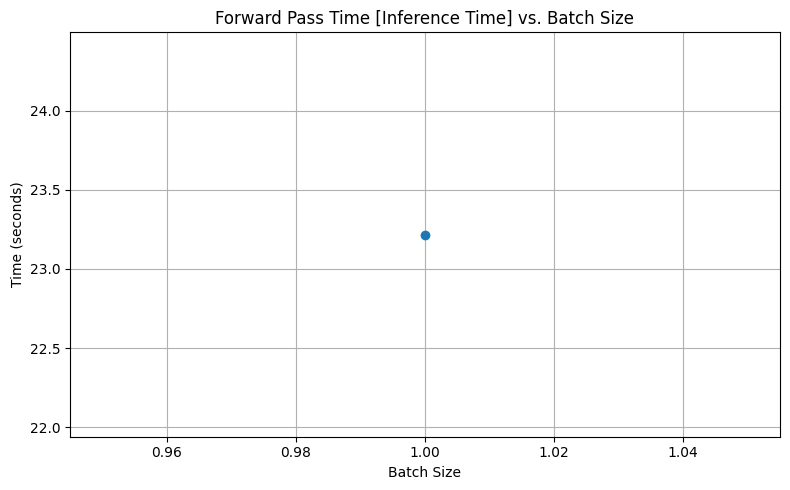

In [ ]:
# Run the benchmarking
benchmark_batch_sizes(model)

#### Local usage

Repo installation:

```bash
git clone https://github.com/gastruc/AnySat.git
cd AnySat
pip install -e AnySat
```



In [ ]:
from hubconf import AnySat

model = AnySat.from_pretrained('base', flash_attn=False) #Set flash_attn=True if you have flash-attn module installed (url flash attn)
device = "cuda" #If you want to run on GPU default is cpu

#### Experiments Reproduction

All experiments are available in the [experiments](https://github.com/gastruc/AnySat/tree/main/experiments) folder.

For the reproduction of AnySat envirnoment run:

```bash
# clone project
git clone https://github.com/gastruc/anysat
cd anysat

# [OPTIONAL] create conda environment
conda create -n anysat python=3.9
conda activate anysat

# install requirements
pip install -r requirements.txt

# Create data folder where you can put your datasets
mkdir data
# Create logs folder
mkdir logs
```

And Then run the experiment you want:

```bash
# Run AnySat pretraining on GeoPlex
python src/train.py exp=GeoPlex_AnySAT

# Run AnySat finetuning on BraDD-S1TS
python src/train.py exp=BraDD_AnySAT_FT

# Run AnySat linear probing on BraDD-S1TS
python src/train.py exp=BraDD_AnySAT_LP
```

You can modify through hydra all parameters you want. For example to train a Small version of AnySat on GeoPlex datasets, run:

```bash
python src/train.py exp=GeoPlex_AnySAT model=Any_Small_multi
```



## Inference on AnySat

#### Template of data

We are gonna use an example from TreeSatAI-TS dataset.

In [ ]:
def day_number_in_year(date_arr, place=4):
    day_number = []
    for date_string in date_arr:
        date_object = datetime.strptime(str(date_string).split('_')[place][:8], '%Y%m%d')
        day_number.append(date_object.timetuple().tm_yday) # Get the day of the year
    return torch.tensor(day_number)


with rasterio.open('.media/Abies_alba_1_1005_WEFL_NLF.tif') as src:
    aerial = torch.FloatTensor(src.read())[:, 2:302, 2:302]

with h5py.File('.media/Abies_alba_1_1005_WEFL_NLF.h5', 'r') as file:
    s1_dates = day_number_in_year(file["sen-1-asc-products"][:])
    s2 = torch.tensor(file["sen-2-data"][:])
    s2_dates = day_number_in_year(file["sen-2-products"][:], place=2)

s1 = torch.load('.media/Abies_alba_1_1005_WEFL_NLF.pth')

In [ ]:
# Normalize data. AnySat requires data to be normalized.

MEAN_AERIAL = torch.tensor([
        150.89349365234375,
        92.7138900756836,
        84.85437774658203,
        80.70423889160156
    ]).float()
STD_AERIAL = torch.tensor([
        36.764923095703125,
        27.62498664855957,
        22.479450225830078,
        26.733688354492188
    ]).float()
MEAN_S2 = torch.tensor([
        4304.32958984375,
        4159.2666015625,
        4057.776611328125,
        4328.951171875,
        4571.22119140625,
        4644.87109375,
        4837.2470703125,
        4700.2578125,
        2823.264404296875,
        2319.97021484375
    ]).float()
STD_S2 = torch.tensor([
        3537.99755859375,
        3324.23486328125,
        3270.070068359375,
        3250.530029296875,
        2897.391357421875,
        2754.4970703125,
        2821.521484375,
        2625.952392578125,
        1731.56298828125,
        1549.3028564453125
    ]).float()
MEAN_S1 = torch.tensor([
        3.2893013954162598,
        -3.682938814163208,
        0.6116273403167725
    ]).float()
STD_S1 = torch.tensor([
        40.11152267456055,
        40.535335540771484,
        1.0343183279037476
    ]).float()

aerial = (aerial - MEAN_AERIAL[:, None, None]) / STD_AERIAL[:, None, None]
s2 = (s2 - MEAN_S2[:, None, None]) / STD_S2[:, None, None]
s1 = (s1 - MEAN_S1[:, None, None]) / STD_S1[:, None, None]

In [ ]:
print("aerial shape", aerial.unsqueeze(0).shape)
print("s2 shape", s2.unsqueeze(0).shape)
print("s2_dates shape", s2_dates.unsqueeze(0).shape)
print("s1 shape", s1.unsqueeze(0).shape)
print("s1_dates shape", s1_dates.unsqueeze(0).shape)

aerial shape torch.Size([1, 4, 300, 300])
s2 shape torch.Size([1, 146, 10, 6, 6])
s2_dates shape torch.Size([1, 146])
s1 shape torch.Size([1, 60, 3, 6, 6])
s1_dates shape torch.Size([1, 60])


To get features from an observation of a batch of observations, you need to provide to the model a dictionnary where keys are from the list:
| Dataset       | Description                       | Tensor Size                                          | Channels                                  | Resolution |
|---------------|-----------------------------------|-----------------------------------------|-------------------------------------------|------------|
| aerial        | Single date tensor |Bx4xHxW                                              | RGB, NiR                                  | 0.2m       |
| aerial-flair  | Single date tensor |Bx5xHxW                                              | RGB, NiR, Elevation                       | 0.2m       |
| spot          | Single date tensor |Bx3xHxW                                              | RGB                                       | 1m         |
| naip          | Single date tensor |Bx4xHxW                                               | RGB                                       | 1.25m      |
| s2            | Time series tensor |BxTx10xHxW                                          | B2, B3, B4, B5, B6, B7, B8, B8a, B11, B12 | 10m        |
| s1-asc        | Time series tensor |BxTx2xHxW                                             | VV, VH                                     | 10m        |
| s1            | Time series tensor |BxTx3xHxW                                            | VV, VH, Ratio                             | 10m        |
| alos          | Time series tensor |BxTx3xHxW                                            | HH, HV, Ratio                             | 30m        |
| l7            | Time series tensor |BxTx6xHxW                                            | B1, B2, B3, B4, B5, B7                    | 30m        |
| l8            | Time series tensor |BxTx11xHxW                                           | B8, B1, B2, B3, B4, B5, B6, B7, B9, B10, B11 | 10m        |
| modis         | Time series tensor |BxTx7xHxW                                            | B1, B2, B3, B4, B5, B6, B7                | 250m       |

In [ ]:
data = {
    "aerial": aerial.unsqueeze(0), #1 batch size, 4 channels, 300x300 pixels
    "s2": s2.unsqueeze(0), #1 batch size, 146 dates, 10 channels, 6x6 pixels
    "s2_dates": s2_dates.unsqueeze(0),
    "s1": s1.unsqueeze(0), #1 batch size, 60 dates, 3 channels, 6x6 pixels
    "s1_dates": s1_dates.unsqueeze(0),
}

# [PART W/ OWN MODIFICATIONS]

In [ ]:
# Define the path to the folder containing your Sentinel-1 images
directory_path = '.media/BioMassters/S1_files/sample_batch' # original 256x256 images
directory_path = '.media/BioMassters/S1_files/sample_batch_cropped_250' # cropped images to 250x250 pixels

file_names = os.listdir(directory_path)
file_names = sorted(os.listdir(directory_path))

### Data option 1: Using only Images of same time (month) of the year -> Timeseries dimension = 1

In [ ]:
"""
# Initialize an empty list to store the pixel values from the first band
image_tensors = []

# Iterate over all files in the folder
for filename in os.listdir(directory_path):
    # Check if the filename ends with '_S1_04.tif'(SAR images of January)
    if filename.endswith('_S1_04.tif'):
        # Construct the full file path
        file_path = os.path.join(directory_path, filename)

        # Open the TIFF file using rasterio
        with rasterio.open(file_path) as src:
            # Read all the bands (this returns a 3D numpy array of shape (bands, height, width))
            img_array = src.read()  # img_array shape: (bands, height, width)

            # Extract the first two bands (index 0 and 1)
            band1 = img_array[0, :, :]  # Shape: (height, width)
            band2 = img_array[1, :, :]  # Shape: (height, width)

            # Convert the first two bands to PyTorch tensors
            band1_tensor = torch.tensor(band1, dtype=torch.float32)  # Tensor of shape (height, width)
            band2_tensor = torch.tensor(band2, dtype=torch.float32)  # Tensor of shape (height, width)

            # Stack the two tensors along a new dimension (2 channels)
            combined_tensor = torch.stack([band1_tensor, band2_tensor], dim=0)  # Shape: (2, height, width)

            # Append the combined tensor to the list
            image_tensors.append(combined_tensor)

# Concatenate all tensors along the batch dimension (dim=0) to form a single tensor
# The resulting tensor will have the shape (num_images, 2, height, width)
concatenated_tensor = torch.stack(image_tensors)

# Print the shape of the resulting tensor
print(f"Concatenated tensor shape: {concatenated_tensor.shape}")

# Optionally, save the tensor to disk
#torch.save(concatenated_tensor, 'concatenated_tensor.pt')
"""

Concatenated tensor shape: torch.Size([3, 2, 256, 256])


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


### Data option 2: Using only images of same objective at different times (months) of the year -> Timeseries dimension = 12

In [ ]:
# Initialize an empty list to store the pixel values from the first band
image_tensors = []

# Iterate over all files in the folder
for i in range(12):

        # Construct the full file path
        file_path = os.path.join(directory_path, file_names[i])

        # Open the TIFF file using rasterio
        with rasterio.open(file_path) as src:
            # Read all the bands (this returns a 3D numpy array of shape (bands, height, width))
            img_array = src.read()  # img_array shape: (bands, height, width)

            # Extract the first two bands (index 0 and 1)
            band1 = img_array[0, :, :]  # Shape: (height, width)
            band2 = img_array[1, :, :]  # Shape: (height, width)

            # Convert the first two bands to PyTorch tensors
            band1_tensor = torch.tensor(band1, dtype=torch.float32)  # Tensor of shape (height, width)
            band2_tensor = torch.tensor(band2, dtype=torch.float32)  # Tensor of shape (height, width)

            # Stack the two tensors along a new dimension (2 channels)
            combined_tensor = torch.stack([band1_tensor, band2_tensor], dim=0)  # Shape: (2, height, width)

            # Append the combined tensor to the list
            image_tensors.append(combined_tensor)

# Concatenate all tensors along the batch dimension (dim=0) to form a single tensor
# The resulting tensor will have the shape (num_images, 2, height, width)
concatenated_tensor = torch.stack(image_tensors)

# Print the shape of the resulting tensor
print(f"Concatenated tensor shape: {concatenated_tensor.shape}")

# Optionally, save the tensor to disk
#torch.save(concatenated_tensor, 'concatenated_tensor.pt')


Concatenated tensor shape: torch.Size([12, 2, 250, 250])


### Data normalization (required)

In [ ]:
# Assume 'sensor_data' is your 4D tensor of shape [12, 2, 250, 250]
# where:
# - 12 time points
# - 2 bands (channels)
# - 250 x 250 pixels (height x width)

# Example: Creating a tensor of random values for demonstration purposes
# Replace this with your actual tensor
sensor_data = concatenated_tensor  # Example tensor

# Step 0: Check the mean and standard deviation of the un-normalized tensor for each band
for band in range(sensor_data.shape[1]):
    band_data = sensor_data[:, band, :, :]
    print(f"Band {band + 1}:")
    print(f"Mean: {band_data.mean():.6f}")
    print(f"Standard Deviation: {band_data.std():.6f}")

# Step 1: Normalize the tensor for each band
# Loop over the bands (channels) and normalize
for band in range(sensor_data.shape[1]):  # loop over the 2 bands
    band_data = sensor_data[:, band, :, :]  # Select data of the current band
    mean = band_data.mean()  # Calculate mean of the current band
    std = band_data.std()  # Calculate standard deviation of the current band

    # Normalize the band: subtract mean and divide by standard deviation
    sensor_data[:, band, :, :] = (band_data - mean) / std

# Step 2: Check the mean and standard deviation of the normalized tensor for each band
for band in range(sensor_data.shape[1]):
    band_data = sensor_data[:, band, :, :]
    print(f"Band {band + 1}:")
    print(f"Mean: {band_data.mean():.6f}")
    print(f"Standard Deviation: {band_data.std():.6f}")

Band 1:
Mean: -10.897809
Standard Deviation: 3.590678
Band 2:
Mean: -17.028809
Standard Deviation: 3.486322
Band 1:
Mean: -0.000000
Standard Deviation: 1.000000
Band 2:
Mean: 0.000000
Standard Deviation: 1.000000


# Additionally required Data Definition + Formatting
##### -> see below: "Note that time series requires a `_dates` companion tensor containing the day of the year: 01/01 = 0, 31/12=364."

In [ ]:
# Taking exemplary day dates in the middle of each respective month

#s1_asc_dates = torch.tensor([258, 258, 258]) # September only
#s1_asc_dates = torch.tensor([15, 46, 74, 105, 135, 166, 197, 227, 258, 288, 319, 350]) # each month of the year, start with January
s1_asc_dates = torch.tensor([258, 288, 319, 350, 15, 46, 74, 105, 135, 166, 197, 227]) # each month of the year, starting with September (same order as in BioMassters data: {file_prefix}_00.tif (= September), {file_prefix}_01.tif (= October), ...)
#s1_asc_dates = torch.tensor([15, 15, 15]) # January only

data = {"s1-asc": concatenated_tensor.unsqueeze(0), # Dimensionality requirements for S1-asc data (see table): [BatchSize x Dates (Time) x Bands/Channels x Height x Width]
        "s1-asc_dates": s1_asc_dates.unsqueeze(0)} # adding dimensionality for either batch size or timeseries, dependent on selected data option above

In [ ]:
data["s1-asc"].shape, data["s1-asc_dates"].shape

(torch.Size([1, 12, 2, 250, 250]), torch.Size([1, 12]))

# [UNMODIFIED] Feature Extraction

Note that time series requires a `_dates` companion tensor containing the day of the year: 01/01 = 0, 31/12=364.

Decide on:
- **Patch size** (in m, must be a multiple of 10): adjust according to the scale of your tiles and GPU memory. In general, avoid having more than 1024 patches per tile.
- **Output type**: Choose between:
  - `'tile'`: Single vector per tile
  - `'patch'`: A vector per patch
  - `'dense'`: A vector per sub-patch. Doubles the size to the vectors
  - `'all'`: A vector per patch with class token at first position

⚠️ For segmentation tasks, use 'dense' argument!

The sub patches are `1x1` pixels for time series and `10x10` pixels for VHR images. If using `output='dense'`, specify the `output_modality`.
Scale should divide the spatial cover of all modalities and be a multiple of 10

In [ ]:
features = model(data, patch_size=10, output='tile')
print(features.shape)

In [ ]:
features = model(data, patch_size=10, output='patch')
print(features.shape)

torch.Size([1, 6, 6, 768])


In [ ]:
features = model(data, patch_size=20, output='patch')
print(features.shape)

torch.Size([1, 3, 3, 768])


In [ ]:
features = model(data, patch_size=60, output='patch')
print(features.shape)

torch.Size([1, 1, 1, 768])


In [ ]:
features = model(data, patch_size=20, output='dense', output_modality="aerial")
print(features.shape)

torch.Size([1, 30, 30, 1536])


In [ ]:
features = model(data, patch_size=20, output='dense', output_modality="s2")
print(features.shape)

torch.Size([1, 6, 6, 1536])
